In [2]:
from sklearn.metrics import pairwise_distances

print("sklearn works")

sklearn works


In [3]:
from transformers import BertTokenizer

print("transformers works")

transformers works


In [4]:
import sys
import sklearn
import transformers

print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("Transformers:", transformers.__version__)

Python: 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
Scikit-learn: 1.7.2
Transformers: 5.12.0


In [5]:
import torch

print(torch.cuda.is_available())

False


In [6]:
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("BERT loaded successfully!")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1723.36it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

BERT loaded successfully!


In [7]:
print("df" in globals())

False


In [8]:
import pandas as pd

df = pd.read_csv("D:\\fake-news-classifier\\data\\WELFake_Dataset.csv")

print(df.shape)
df.head()

(72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [9]:
df["content"] = (
    df["title"].fillna("")
    + " "
    + df["text"].fillna("")
)

df = df[["content", "label"]]

print(df.shape)
df.head()

(72134, 2)


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


In [10]:
torch.cuda.is_available()

False

In [11]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df,
    train_size=3000,
    stratify=df["label"],
    random_state=42
)

print(df_sample.shape)

(3000, 2)


In [12]:
print(df_sample["label"].value_counts(normalize=True))

label
1    0.514333
0    0.485667
Name: proportion, dtype: float64


In [13]:
train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.30,
    stratify=df_sample["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2100, 2)
(450, 2)
(450, 2)


In [14]:
print(train_df["label"].value_counts(normalize=True))
print()
print(val_df["label"].value_counts(normalize=True))
print()
print(test_df["label"].value_counts(normalize=True))

label
1    0.514286
0    0.485714
Name: proportion, dtype: float64

label
1    0.515556
0    0.484444
Name: proportion, dtype: float64

label
1    0.513333
0    0.486667
Name: proportion, dtype: float64


In [15]:
import torch
from torch.utils.data import Dataset

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

print("Dataset class ready!")

Dataset class ready!


In [16]:
train_dataset = NewsDataset(
    train_df["content"],
    train_df["label"],
    tokenizer
)

val_dataset = NewsDataset(
    val_df["content"],
    val_df["label"],
    tokenizer
)

test_dataset = NewsDataset(
    test_df["content"],
    test_df["label"],
    tokenizer
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

2100
450
450


In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8
)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

263
57
57


In [18]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([8, 128])
torch.Size([8, 128])
torch.Size([8])


In [19]:
device = torch.device("cpu")

print(device)

cpu


In [20]:
model.to(device)

print("Model moved to:", device)

Model moved to: cpu


In [21]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

total_steps = len(train_loader) * 2

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print("Optimizer and scheduler ready!")
print(type(optimizer))
print(type(scheduler))

Optimizer and scheduler ready!
<class 'torch.optim.adamw.AdamW'>
<class 'torch.optim.lr_scheduler.LambdaLR'>


In [22]:
print("optimizer" in globals())
print("scheduler" in globals())

True
True


In [23]:
print("model" in globals())
print("tokenizer" in globals())
print("train_loader" in globals())
print("optimizer" in globals())
print("scheduler" in globals())

True
True
True
True
True


In [24]:
print(train_df.columns)

Index(['content', 'label'], dtype='str')


In [25]:
print(type(optimizer))
print(total_steps)

<class 'torch.optim.adamw.AdamW'>
526


In [26]:
import torch
from tqdm.auto import tqdm

device = torch.device("cpu")
model.to(device)

epochs = 2

for epoch in range(epochs):

    model.train()

    total_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{epochs}"
    )

    for batch in progress_bar:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_loss = total_loss / len(train_loader)

    print(
        f"\nEpoch {epoch + 1} Average Loss: {avg_loss:.4f}"
    )

print("Training complete!")

Epoch 1/2: 100%|██████████| 263/263 [50:54<00:00, 11.61s/it, loss=0.0175]



Epoch 1 Average Loss: 0.2475


Epoch 2/2: 100%|██████████| 263/263 [57:54<00:00, 13.21s/it, loss=0.0067]


Epoch 2 Average Loss: 0.0414
Training complete!


In [27]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

accuracy = accuracy_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

cm = confusion_matrix(
    true_labels,
    predictions
)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

print("\nClassification Report:")
print(
    classification_report(
        true_labels,
        predictions
    )
)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.9911111111111112
F1 Score: 0.9913419913419913

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       219
           1       0.99      0.99      0.99       231

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450


Confusion Matrix:
[[217   2]
 [  2 229]]


In [28]:
model.save_pretrained("saved_model")
tokenizer.save_pretrained("saved_model")

print("Model saved successfully!")

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it]


Model saved successfully!


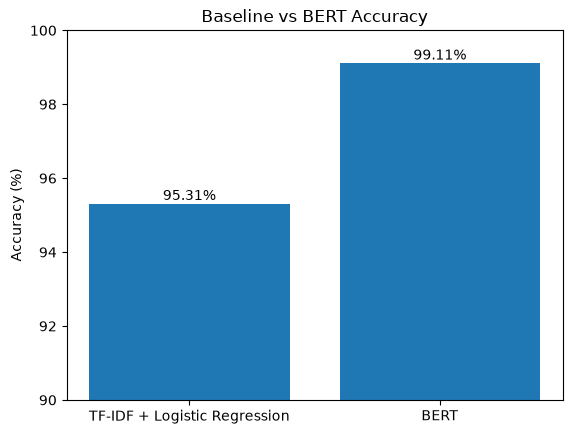

In [31]:
import matplotlib.pyplot as plt

models = ["TF-IDF + Logistic Regression", "BERT"]
scores = [95.31, 99.11]

bars = plt.bar(models, scores)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.1,
        f"{score:.2f}%",
        ha="center"
    )

plt.ylabel("Accuracy (%)")
plt.title("Baseline vs BERT Accuracy")
plt.ylim(90, 100)

plt.show()